# Experimento B — Ablación por Subconjunto de Imágenes
**IIC3912 Tópicos Avanzados de Gráfica Computacional — Tarea 2**


# Instalación de dependencias y conexión con drive

In [1]:
# Install CUDA 12 toolkit (doesn't replace the driver, just the toolkit)
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.1-1_all.deb -q
!dpkg -i cuda-keyring_1.1-1_all.deb
!apt-get update -qq
!apt-get install -y cuda-toolkit-12-8 -qq

# Point to CUDA 12
import os
os.environ["CUDA_HOME"] = "/usr/local/cuda-12.8"
os.environ["PATH"] = "/usr/local/cuda-12.8/bin:" + os.environ["PATH"]

# Then install the cuda12 wheel
!pip uninstall pycolmap pycolmap-cuda12 -y -q
!pip install pycolmap-cuda12 --no-cache-dir -q

(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack cuda-keyring_1.1-1_all.deb ...
Unpacking cuda-keyring (1.1-1) over (1.1-1) ...
Setting up cuda-keyring (1.1-1) ...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Unable to correct problems, you have held broken packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 199.1 MB/s eta 0:00:00


In [2]:
!pip install pycolmap-cuda12 pandas -q

import os, shutil, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycolmap
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import display


print('pycolmap:', pycolmap.__version__)

pycolmap: 4.0.4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

SCENES    = ['garden', 'bicycle', 'bonsai', 'counter']
IMG_SCALE = 4

DRIVE_BASE = Path('/content/drive/MyDrive/tarea2_mipnerf')
BASE       = Path('/content/colmap_work')
DRIVE_BASE.mkdir(parents=True, exist_ok=True)

def scene_paths(scene):
    return {
        'drive'    : DRIVE_BASE / scene,
        'images'   : BASE / scene / 'images',
        'sparse'   : BASE / scene / 'sparse',
        'db'       : BASE / scene / 'colmap.db',
        'official' : DRIVE_BASE / scene / 'sparse' / '0',
    }

for scene in SCENES:
    p = scene_paths(scene)
    for d in [p['images'], p['sparse'] / 'student', p['sparse'] / 'official']:
        d.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [4]:
DATASET_URL = 'https://storage.googleapis.com/gresearch/refraw360/360_v2.zip'
ZIP_PATH    = DRIVE_BASE / '360_v2.zip'

def download_and_extract(scene):
    dst = DRIVE_BASE / scene
    if dst.exists():
        print(f'[{scene}] ya en Drive')
        return
    if not ZIP_PATH.exists():
        print('Descargando dataset (~1.8 GB)...')
        ret = os.system(f'wget -q --show-progress -O "{ZIP_PATH}" "{DATASET_URL}"')
        if ret != 0:
            raise RuntimeError('Descarga fallida. Sube el zip manualmente a Drive.')
    print(f'[{scene}] extrayendo...')
    ret = os.system(f'unzip -q "{ZIP_PATH}" "{scene}/*" -d "{DRIVE_BASE}"')
    if ret != 0 or not dst.exists():
        raise RuntimeError(f'Error extrayendo {scene}')
    print(f'[{scene}] listo en {dst}')

def prepare_images(scene):
    paths = scene_paths(scene)
    dst   = paths['images']
    existing = list(dst.glob('*.jpg')) + list(dst.glob('*.JPG')) + list(dst.glob('*.png'))
    if existing:
        print(f'[{scene}] {len(existing)} imágenes ya en local')
        return
    scale_folder = f'images_{IMG_SCALE}' if IMG_SCALE > 1 else 'images'
    src = paths['drive'] / scale_folder
    if not src.exists():
        src = paths['drive'] / 'images'
        print(f'[{scene}] {scale_folder}/ no encontrada → usando images/')
    imgs = sorted(list(src.glob('*.jpg')) + list(src.glob('*.JPG')) + list(src.glob('*.png')))
    print(f'[{scene}] copiando {len(imgs)} imágenes desde {src.name}...')
    for img_path in imgs:
        shutil.copy(str(img_path), str(dst / img_path.name))
    with PILImage.open(list(dst.glob('*'))[0]) as im:
        print(f'[{scene}] resolución: {im.size} | total: {len(imgs)} imgs')

# Descargar y preparar las 4 escenas
for scene in SCENES:
    download_and_extract(scene)
    prepare_images(scene)

Descargando dataset (~1.8 GB)...
[garden] extrayendo...
[garden] listo en /content/drive/MyDrive/tarea2_mipnerf/garden
[garden] 23 imágenes ya en local
[bicycle] extrayendo...
[bicycle] listo en /content/drive/MyDrive/tarea2_mipnerf/bicycle
[bicycle] 1 imágenes ya en local
Descargando dataset (~1.8 GB)...
[bonsai] extrayendo...
[bonsai] listo en /content/drive/MyDrive/tarea2_mipnerf/bonsai
[bonsai] 292 imágenes ya en local
Descargando dataset (~1.8 GB)...
[counter] extrayendo...
[counter] listo en /content/drive/MyDrive/tarea2_mipnerf/counter
[counter] 240 imágenes ya en local


## Diseño del experimento

Se evalúan **3 fracciones** del dataset: 10 %, 20 % y 50 % de las imágenes
disponibles por escena. Para cada fracción se selecciona una muestra aleatoria con
**semilla fija = 42** para garantizar reproducibilidad.

**Métricas reportadas por (escena, fracción):**
- (a) Imágenes registradas y porcentaje sobre el total del subconjunto.
- (b) Número de puntos 3D reconstruidos.
- (c) Error de reproyección promedio (px).
- (d) Número de componentes conexas (reconstrucciones separadas devueltas por COLMAP).
- (e) Tiempo de ejecución (s).
- (f) **Métrica propia longitud media de track**: número medio de imágenes que observan
      cada punto 3D. Captura la redundancia y estabilidad de la reconstrucción (un punto
      visto desde muchos ángulos es más robusto que uno visto desde pocos).

## Pipeline SfM con pycolmap

In [7]:
FRACTIONS = [0.1, 0.2, 0.5]
SEED      = 42

def get_img_dir(scene):
    """Retorna el directorio de imágenes: local si tiene archivos, sino Drive."""
    local = BASE / scene / 'images'
    local_imgs = [f for f in local.iterdir() if f.suffix.lower() in ('.jpg', '.png')] if local.exists() else []
    if local_imgs:
        return local
    scale_folder = f'images_{IMG_SCALE}' if IMG_SCALE > 1 else 'images'
    drive_dir = DRIVE_BASE / scene / scale_folder
    if not drive_dir.exists():
        drive_dir = DRIVE_BASE / scene / 'images'
    return drive_dir

def run_sfm(scene, fraction, seed=SEED, verbose=False):
    """
    Ejecuta el pipeline COLMAP sobre un subconjunto aleatorio de imágenes.
    Devuelve un dict con las métricas del experimento.
    """
    img_dir  = get_img_dir(scene)
    all_imgs = sorted([f.name for f in img_dir.iterdir() if f.suffix.lower() in ('.jpg', '.png')])
    n_total  = len(all_imgs)
    n_subset = max(3, int(round(n_total * fraction)))

    rng    = random.Random(seed)
    subset = sorted(rng.sample(all_imgs, n_subset))

    run_tag  = f'{scene}_f{int(fraction * 100):03d}'
    db_path  = BASE / 'ablation' / run_tag / 'db.db'
    out_path = BASE / 'ablation' / run_tag / 'sparse'
    db_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.mkdir(parents=True, exist_ok=True)
    if db_path.exists():
        db_path.unlink()

    t0 = time.time()

    # pycolmap 4.x usa image_names (no image_list)
    pycolmap.extract_features(
        database_path=str(db_path),
        image_path=str(img_dir),
        image_names=subset,
    )

    print("Finished feature extraction")

    pycolmap.match_exhaustive(
        database_path=str(db_path)
    )

    print("Finished matching")

    maps = pycolmap.incremental_mapping(
        database_path=str(db_path),
        image_path=str(img_dir),
        output_path=str(out_path),
    )

    print("Finished mapping")

    elapsed = time.time() - t0

    if not maps:
        return {
            'scene': scene, 'fraction': fraction,
            'n_input': n_subset, 'n_registered': 0, 'pct_registered': 0.0,
            'n_points3d': 0, 'mean_reproj_error': float('nan'),
            'n_components': 0, 'time_s': round(elapsed, 1),
            'mean_track_length': float('nan'),
        }

    rec          = maps[max(maps, key=lambda k: maps[k].num_reg_images())]
    n_components = len(maps)
    n_reg        = rec.num_reg_images()
    n_pts        = rec.num_points3D()

    errors    = [p.error for p in rec.points3D.values() if p.error > 0]
    mean_err  = float(np.mean(errors)) if errors else float('nan')

    track_lengths = [len(p.track.elements) for p in rec.points3D.values()]
    mean_track    = float(np.mean(track_lengths)) if track_lengths else float('nan')

    if verbose:
        print(f'  [{scene} f={fraction:.0%}] {n_reg}/{n_subset} imgs | '
              f'{n_pts:,} pts | err={mean_err:.3f}px | comp={n_components} | '
              f't={elapsed:.0f}s | track={mean_track:.1f}')

    return {
        'scene': scene, 'fraction': fraction,
        'n_input': n_subset, 'n_registered': n_reg,
        'pct_registered': round(100.0 * n_reg / n_subset, 1),
        'n_points3d': n_pts,
        'mean_reproj_error': round(mean_err, 3),
        'n_components': n_components,
        'time_s': round(elapsed, 1),
        'mean_track_length': round(mean_track, 2),
    }

print('Pipeline definido. Fracciones:', FRACTIONS)

Pipeline definido. Fracciones: [0.1, 0.2, 0.5]


## Ejecución de la ablación

Se itera sobre las 4 escenas × 3 fracciones = 12 corridas. El tiempo total depende del
hardware de Colab; en GPU puede tomar 15–30 minutos. Los resultados se guardan
progresivamente para no perder datos ante una desconexión.

In [9]:
results = []

for scene in SCENES:
    print(f'\n=== Escena: {scene} ===')
    for frac in FRACTIONS:
        print(f'  Fracción {frac:.0%} ...', end=' ', flush=True)
        row = run_sfm(scene, frac, seed=SEED, verbose=True)
        results.append(row)

df = pd.DataFrame(results)
print('\n✓ Ablación completa.')
display(df)



RESULTS_PATH = DRIVE_BASE / 'ablation_results.csv'
df.to_csv(str(RESULTS_PATH), index=False)
print(f'Resultados guardados en Drive: {RESULTS_PATH}')


=== Escena: garden ===
  Fracción 10% ... Finished feature extraction
Finished matching
Finished mapping
  [garden f=10%] 10/18 imgs | 3,001 pts | err=0.299px | comp=2 | t=10s | track=3.5
  Fracción 20% ... Finished feature extraction
Finished matching
Finished mapping
  [garden f=20%] 37/37 imgs | 17,155 pts | err=0.337px | comp=1 | t=39s | track=4.0
  Fracción 50% ... Finished feature extraction
Finished matching
Finished mapping
  [garden f=50%] 92/92 imgs | 66,676 pts | err=0.388px | comp=1 | t=259s | track=5.7

=== Escena: bicycle ===
  Fracción 10% ... Finished feature extraction
Finished matching
Finished mapping
  [bicycle f=10%] 5/19 imgs | 237 pts | err=0.467px | comp=1 | t=6s | track=3.5
  Fracción 20% ... Finished feature extraction
Finished matching
Finished mapping
  [bicycle f=20%] 11/39 imgs | 636 pts | err=0.563px | comp=2 | t=49s | track=3.8
  Fracción 50% ... Finished feature extraction
Finished matching
Finished mapping
  [bicycle f=50%] 96/97 imgs | 20,253 pts | e

,scene,fraction,n_input,n_registered,pct_registered,n_points3d,mean_reproj_error,n_components,time_s,mean_track_length
0,garden,0.1,18,10,55.6,3001,0.299,2,9.7,3.51
1,garden,0.2,37,37,100.0,17155,0.337,1,38.8,4.01
2,garden,0.5,92,92,100.0,66676,0.388,1,259.3,5.66
3,bicycle,0.1,19,5,26.3,237,0.467,1,5.9,3.46
4,bicycle,0.2,39,11,28.2,636,0.563,2,48.5,3.78
5,bicycle,0.5,97,96,99.0,20253,0.422,1,133.2,4.21
6,bonsai,0.1,29,29,100.0,12669,0.206,2,53.0,3.68
7,bonsai,0.2,58,58,100.0,21682,0.261,1,114.6,4.92
8,bonsai,0.5,146,146,100.0,59584,0.320,1,366.4,6.61
9,counter,0.1,24,13,54.2,1414,0.304,1,7.7,3.21


Resultados guardados en Drive: /content/drive/MyDrive/tarea2_mipnerf/ablation_results.csv


## Tablas de resultados por escena

In [10]:
cols_display = {
    'fraction'          : 'Fracción',
    'n_input'           : 'N imágenes',
    'n_registered'      : 'Imgs. reg.',
    'pct_registered'    : '% reg.',
    'n_points3d'        : 'Puntos 3D',
    'mean_reproj_error' : 'Err. reproy. (px)',
    'n_components'      : 'Comp. conexas',
    'time_s'            : 'Tiempo (s)',
    'mean_track_length' : 'Track medio',
}

TABLES_PATH = DRIVE_BASE / 'ablation_tables.xlsx'

with pd.ExcelWriter(str(TABLES_PATH), engine='openpyxl') as writer:
    for scene in SCENES:
        sub = df[df['scene'] == scene][list(cols_display.keys())].copy()
        sub = sub.rename(columns=cols_display)
        sub['Fracción'] = sub['Fracción'].map(lambda x: f'{x:.0%}')
        sub = sub.reset_index(drop=True)
        print(f'\n--- {scene} ---')
        display(sub)
        sub.to_excel(writer, sheet_name=scene, index=False)

print(f'\nTablas guardadas en Drive: {TABLES_PATH}')



--- garden ---


,Fracción,N imágenes,Imgs. reg.,% reg.,Puntos 3D,Err. reproy. (px),Comp. conexas,Tiempo (s),Track medio
0,10%,18,10,55.6,3001,0.299,2,9.7,3.51
1,20%,37,37,100.0,17155,0.337,1,38.8,4.01
2,50%,92,92,100.0,66676,0.388,1,259.3,5.66



--- bicycle ---


,Fracción,N imágenes,Imgs. reg.,% reg.,Puntos 3D,Err. reproy. (px),Comp. conexas,Tiempo (s),Track medio
0,10%,19,5,26.3,237,0.467,1,5.9,3.46
1,20%,39,11,28.2,636,0.563,2,48.5,3.78
2,50%,97,96,99.0,20253,0.422,1,133.2,4.21



--- bonsai ---


,Fracción,N imágenes,Imgs. reg.,% reg.,Puntos 3D,Err. reproy. (px),Comp. conexas,Tiempo (s),Track medio
0,10%,29,29,100.0,12669,0.206,2,53.0,3.68
1,20%,58,58,100.0,21682,0.261,1,114.6,4.92
2,50%,146,146,100.0,59584,0.320,1,366.4,6.61



--- counter ---


,Fracción,N imágenes,Imgs. reg.,% reg.,Puntos 3D,Err. reproy. (px),Comp. conexas,Tiempo (s),Track medio
0,10%,24,13,54.2,1414,0.304,1,7.7,3.21
1,20%,48,48,100.0,5502,0.355,1,16.9,3.87
2,50%,120,120,100.0,25257,0.403,1,102.7,4.79



Tablas guardadas en Drive: /content/drive/MyDrive/tarea2_mipnerf/ablation_tables.xlsx


## Visualizaciones: métricas vs. fracción de imágenes

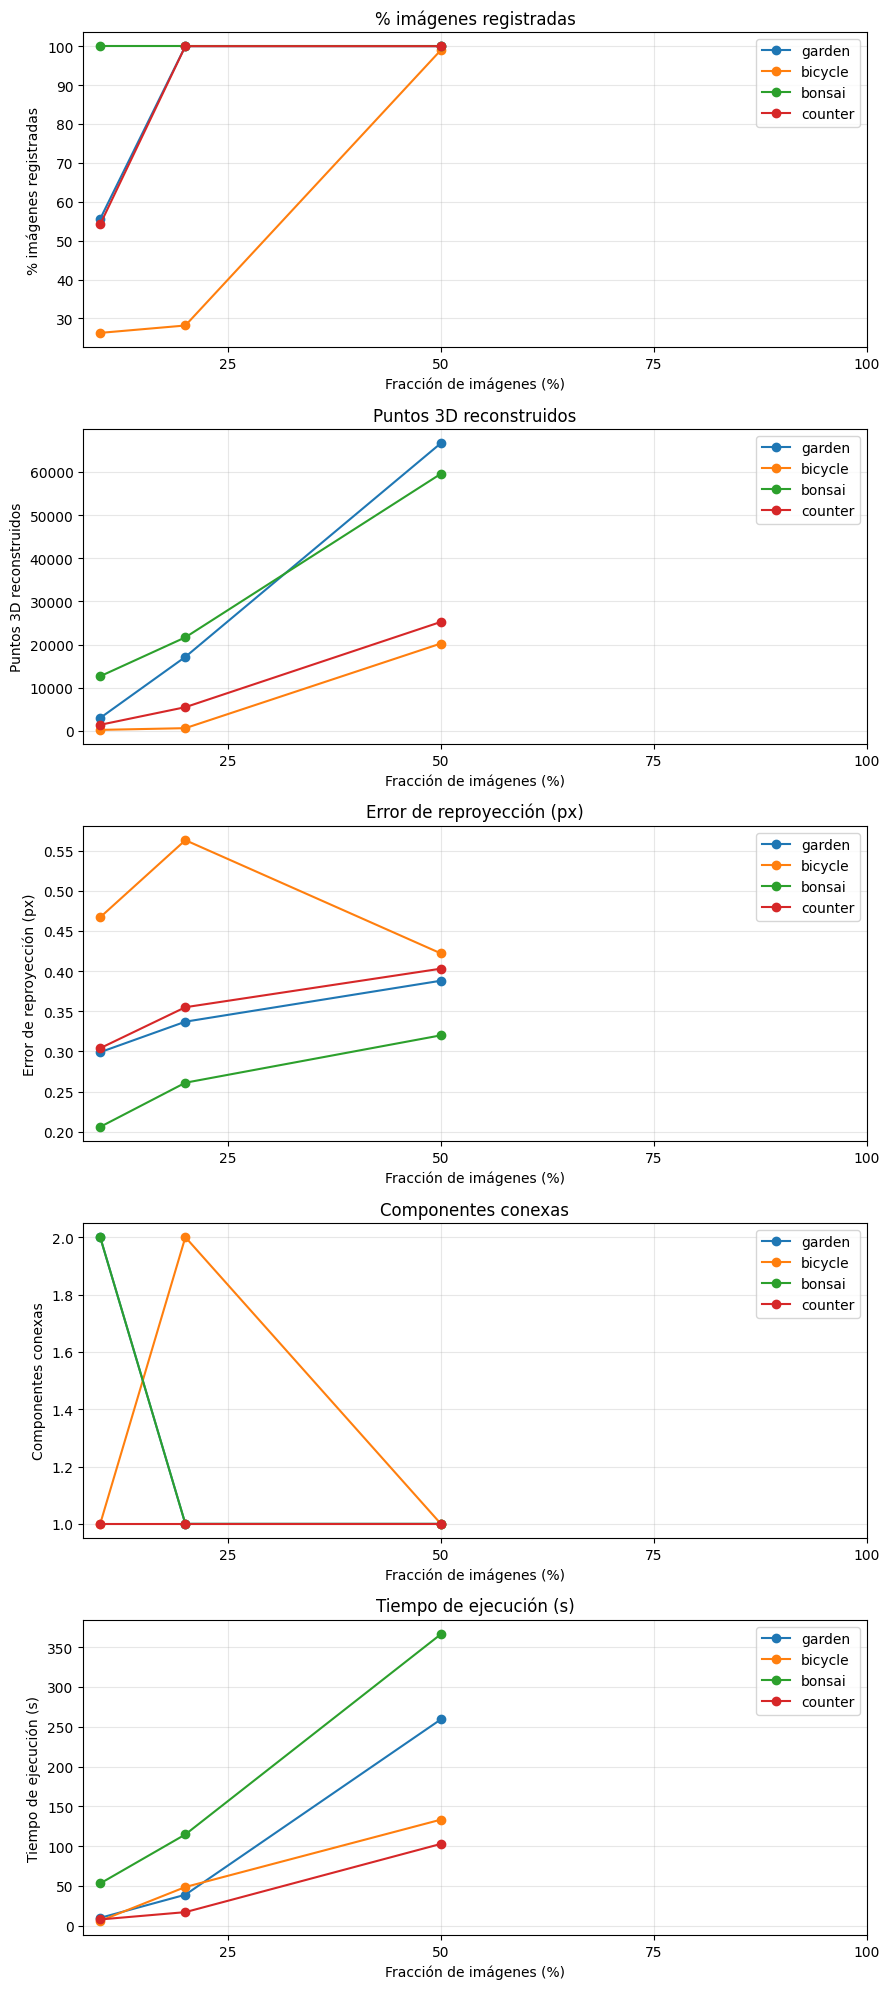

In [11]:
metrics_to_plot = [
    ('pct_registered',    '% imágenes registradas'),
    ('n_points3d',        'Puntos 3D reconstruidos'),
    ('mean_reproj_error', 'Error de reproyección (px)'),
    ('n_components',      'Componentes conexas'),
    ('time_s',            'Tiempo de ejecución (s)'),
]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(9, 4 * len(metrics_to_plot)))

for ax, (metric, label) in zip(axes, metrics_to_plot):
    for scene in SCENES:
        sub = df[df['scene'] == scene].sort_values('fraction')
        ax.plot(sub['fraction'] * 100, sub[metric], marker='o', label=scene)
    ax.set_xlabel('Fracción de imágenes (%)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks([25, 50, 75, 100])

plt.tight_layout()
plt.savefig('/content/ablation_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## (f) Métrica propia: longitud media de track

**Definición:** la longitud de un *track* es el número de imágenes desde las que se observa
un mismo punto 3D. La longitud media de track promedia este valor sobre todos los puntos 3D
de la reconstrucción principal.

**Justificación:** el error de reproyección y el número de puntos describen *cantidad*,
pero no dicen nada sobre la *fiabilidad* de cada punto. Un punto observado desde muchos
ángulos (track largo) tiene su posición 3D mucho mejor determinada que uno observado desde
sólo 2 imágenes. Con subconjuntos pequeños, los tracks tienden a ser más cortos porque
hay menos imágenes que puedan contribuir. Esta métrica captura así la **redundancia
geométrica** de la reconstrucción, complementando las métricas estándar.

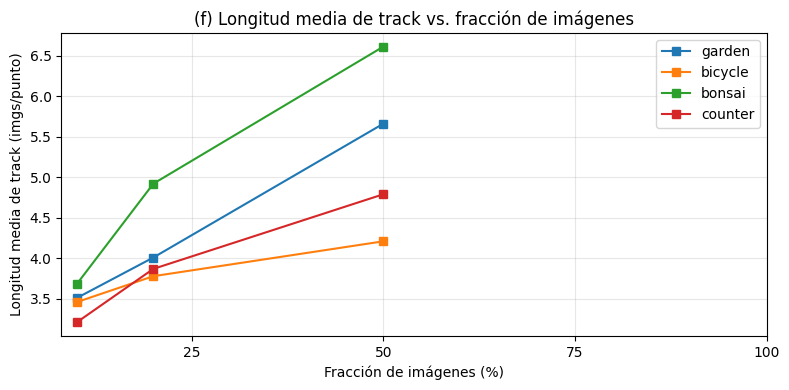

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

for scene in SCENES:
    sub = df[df['scene'] == scene].sort_values('fraction')
    ax.plot(sub['fraction'] * 100, sub['mean_track_length'],
            marker='s', label=scene)

ax.set_xlabel('Fracción de imágenes (%)')
ax.set_ylabel('Longitud media de track (imgs/punto)')
ax.set_title('(f) Longitud media de track vs. fracción de imágenes')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks([25, 50, 75, 100])
plt.tight_layout()
plt.savefig('/content/track_length.png', dpi=120, bbox_inches='tight')
plt.show()

# Discusión

## Comportamiento general al aumentar la fracción

Los resultados muestran tendencias consistentes en las cuatro escenas:

- **% imágenes registradas:** sube con la fracción. A 20% y 50%, garden, bonsai y counter alcanzan 100% de registro. La excepción es bicycle, que a 10% y 20% solo registra el 26–28% de sus imágenes (el pasto homogéneo genera pocos features SIFT reproducibles y con pocas vistas COLMAP no logra conectar las imágenes.)
- **Puntos 3D:** crece monotónicamente en todas las escenas. Garden pasa de 3.001 pts (10%) a 66.676 pts (50%); bonsai de 12.669 a 59.584 pts. El aumento es consistente con más triangulaciones posibles al haber más matches entre pares de imágenes.
- **Error de reproyección:** se mantiene estable y bajo (0.206–0.563 px) en la mayoría de los casos, lo que indica reconstrucciones de buena calidad. El valor más alto se observa en bicycle al 20% (0.563 px), donde con solo 11 imágenes registradas de 39 el bundle adjustment tiene muy pocas restricciones para refinar las poses. Bonsai presenta el error más bajo (0.206 px a 10%), beneficiándose de su textura densa y rica en detalles.
- **Componentes conexas:** garden a 10% produce 2 componentes: la escena se divide en dos sub-reconstrucciones aisladas por falta de overlap entre imágenes. Bonsai a 10% también fragmenta en 2 componentes a pesar de registrar el 100% de sus imágenes, indicando que algunas vistas quedan aisladas geométricamente. Bicycle a 20% igualmente genera 2 componentes. Desde el 50% todas las escenas convergen a 1 componente.
- **Tiempo de ejecución:** crece de forma superlineal con la fracción por el matching exhaustivo. Ejemplos: garden pasa de 9.7s (10%) a 259.3s (50%); bicycle de 5.9s a 133.2s. Bonsai al 50% es el más lento (366.4s) dado su mayor número de imágenes (146). Counter resulta el más eficiente al 50% (102.7s con 120 imgs), lo que sugiere que sus superficies estructuradas generan matching más limpio y SfM más rápido.
- **Longitud media de track:** crece consistentemente con la fracción en todas las escenas (de ~3.2–3.7 a 4.2–6.6 imgs/punto), confirmando que más imágenes producen puntos 3D observados desde más vistas y por tanto más fiables geométricamente.

## Diferencias entre escenas

**Comportamiento outdoor vs. indoor:** Las escenas outdoor (garden, bicycle) muestran mayor varianza en el porcentaje de registro al reducir el subconjunto. Bicycle colapsa a 10–20% porque el fondo de pasto genera pocos keypoints reproducibles. Las escenas indoor (bonsai, counter) recuperan bien desde el 10–20%, aunque bonsai también se fragmenta en componentes a 10%.


## Limitaciones del experimento
- Se usó matching exhaustivo, por lo que las corridas al 50% tomaron entre 2 y 6 minutos cada una. No fue factible correr al 75% o 100% por restricciones de tiempo de cómputo en Colab.
- La muestra aleatoria puede omitir imágenes clave que cierran loops de trayectoria, introduciendo varianza en los resultados.